In [1]:
import muon as mu
import torch
import scanpy as sc
import numpy as np
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mdata = mu.read_h5mu("/scratch/fcaretti/GSE158013/GSM5123951.h5mu")
mdata_original = mdata.copy()

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0

In [3]:
mdata.mod["prot"].X = mdata.mod["prot"].layers["counts"]
mdata.mod["rna"].X = mdata.mod["rna"].layers["counts"]
mdata.mod["atac"].X = mdata.mod["atac"].layers["counts"]

In [4]:
sc.pp.normalize_per_cell(mdata["rna"])
sc.pp.log1p(mdata["rna"])
sc.pp.highly_variable_genes(mdata["rna"], n_top_genes=1000, subset=True)
sc.pp.pca(mdata["rna"], n_comps=50, use_highly_variable=False)
sc.pp.neighbors(mdata["rna"], n_neighbors=10)
sc.tl.umap(mdata["rna"])

/tmp/ipykernel_500788/4005388432.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(mdata["rna"])
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
adata.X seems to be already log-transformed.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


In [5]:
mdata_original["rna"].var["highly_variable"] = mdata["rna"].var["highly_variable"]
mdata["rna"].X = mdata["rna"].layers["counts"]

In [6]:
import anndata as ad
from scvi._constants import REGISTRY_KEYS


rna = mdata["rna"]
atac = mdata["atac"]
protein = mdata["prot"]

In [7]:
# test_mmlda.py – run inside a Jupyter cell or plain python

# -- synthetic dataset (RNA + protein) ---------------------------------
N, G, P = 200, 50, 10
np.random.seed(0)
rna = np.random.negative_binomial(10, 0.3, size=(N, G))
adt = np.random.poisson(20, size=(N, P))
X = np.concatenate([rna, adt], axis=1)
adata = ad.AnnData(X)

# -- scvi setup --------------------------------------------------------
MultimodalAmortizedLDA.setup_anndata(adata, layer=None)  # counts are in .X

model = MultimodalAmortizedLDA(
    adata,
    n_inputs_modalities=[G, P],
    likelihoods=["gamma_poisson", "multinomial"],
    n_topics=8,
    n_hidden=32,
)

print("Built ✓")

# ----- single ELBO on a mini-batch -----------------------------------
dl = model._make_data_loader(adata=adata, batch_size=64)
batch = next(iter(dl))
x = batch[REGISTRY_KEYS.X_KEY]
libs = torch.stack([x[:, :G].sum(1), x[:, G:].sum(1)], 1)
elbo = model.module.get_elbo(x, libs, n_obs=N)
print("ELBO:", elbo)

# ----- tiny training run ---------------------------------------------
model.train(max_epochs=1, batch_size=64, early_stopping=False)
print("trained 1 epoch ✓")

# ----- latent representation  ----------------------------------------
Z = model.get_latent_representation()
print("latent shape:", Z.shape)
assert Z.shape == (N, 8)
print("all good ✨")

Built ✓


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0', 'topics_1'}
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You 

ELBO: 151943.57373046875


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 1/1:   0%|          | 0/1 [00:00<?, ?it/s]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0', 'topics_1'}
  warnings.warn(


Epoch 1/1: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 1/1: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s, v_num=1]
trained 1 epoch ✓
latent shape: (200, 8)
all good ✨


In [8]:
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

MultimodalAmortizedLDA.setup_mudata(mdata)

(AnnData object with n_obs × n_vars = 5805 × 97806
     obs: 'rna:n_genes_by_counts', 'rna:total_counts', 'rna:total_counts_mt', 'rna:pct_counts_mt', 'rna:leiden', 'atac:n_fragments', 'atac:n_duplicate', 'atac:n_mito', 'atac:n_unique', 'atac:altius_count', 'atac:altius_frac', 'atac:gene_bodies_count', 'atac:gene_bodies_frac', 'atac:peaks_count', 'atac:peaks_frac', 'atac:tss_count', 'atac:tss_frac', 'atac:barcodes', 'atac:cell_name', 'atac:well_id', 'atac:chip_id', 'atac:batch_id', 'atac:pbmc_sample_id', 'atac:DoubletScore', 'atac:DoubletEnrichment', 'atac:TSSEnrichment', 'atac:n_genes_by_counts', 'atac:total_counts', 'atac:n_counts', 'atac:leiden', 'prot:total_counts', 'sample', 'well', 'leiden_multiplex', 'leiden_mofa'
     uns: '_scvi_uuid', '_scvi_manager_uuid',
 [1000, 96760, 46])

In [9]:
model = MultimodalAmortizedLDA.from_mudata(
    mdata,
    modality_order=["rna", "prot", "atac"],
    n_topics=8,
    n_hidden=64,
)

In [10]:
model.train(max_epochs=50)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 2 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_2', 'topics_0', 'topics_1'}
  warnings.warn(


Epoch 2/50:   2%|▏         | 1/50 [00:04<03:39,  4.48s/it, v_num=1]

...

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 2 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_2', 'topics_0', 'topics_1'}
  warnings.warn(


Epoch 5/50:   8%|▊         | 4/50 [00:14<02:45,  3.59s/it, v_num=1, elbo_train=6.69e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 2 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_2', 'topics_0', 'topics_1'}
  warnings.warn(


Epoch 6/50:  10%|█         | 5/50 [00:18<02:40,  3.56s/it, v_num=1, elbo_train=6.67e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 1 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 2 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_2', 'topics_0', 'topics_1'}
  warnings.warn(

Detected KeyboardInterrupt, attempting graceful shutdown ...


In [ ]:
df = model.get_latent_representation()

In [ ]:
coord = df.to_numpy()

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0, 0.5, 'UMAP 2')

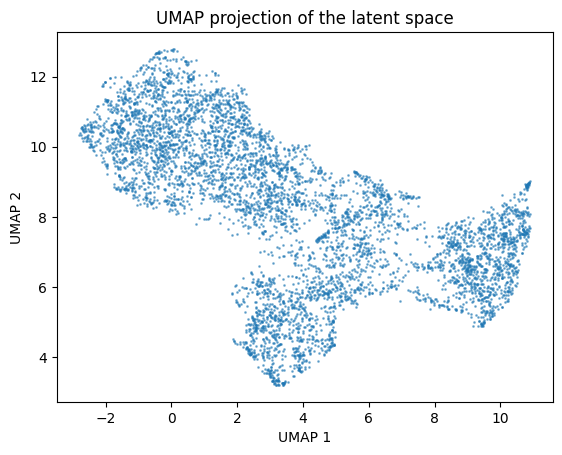

In [ ]:
from umap import UMAP
import matplotlib.pyplot as plt

umap = UMAP(n_components=2)
embedding = umap.fit_transform(coord)

plt.scatter(embedding[:, 0], embedding[:, 1], s=1, alpha=0.5)
plt.title("UMAP projection of the latent space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

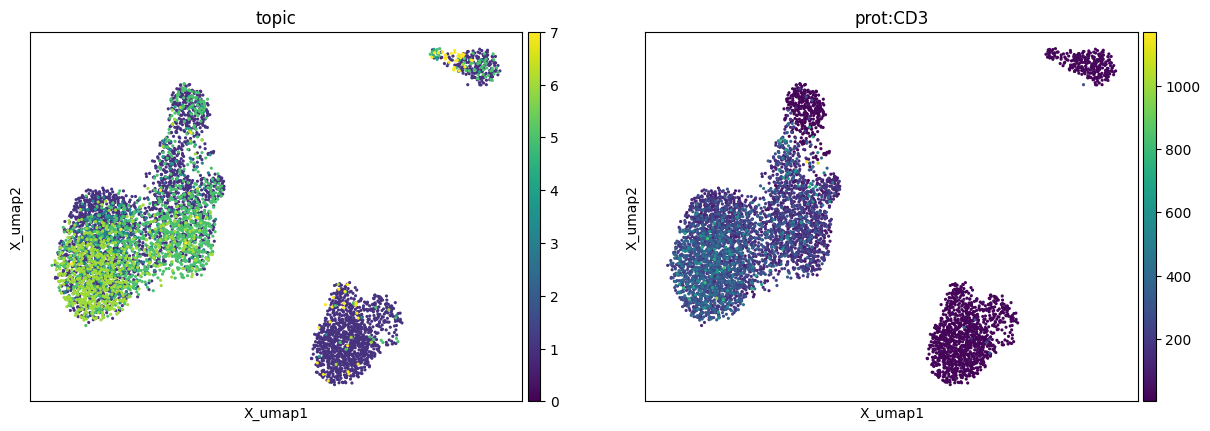

In [ ]:
mdata.obsm["topic_proportions"] = model.get_latent_representation().to_numpy()
mdata.obs["topic"] = np.argmax(model.get_latent_representation().to_numpy(), axis=1)
mu.pl.embedding(mdata, basis="rna:X_umap", color=["topic", "prot:CD3"])